In [58]:
from typing import TypedDict, List, Annotated
from langchain.messages import AnyMessage,AIMessage
from langgraph.graph.message import add_messages
from langchain_core.documents import Document

class GraphState(TypedDict):
    question: str
    generation : Annotated[List[AnyMessage],add_messages ]
    documents: List[Document]

In [59]:
#create a model
from langchain_groq import ChatGroq
grader_model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

from langchain_community.chat_models import ChatOllama
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_community.embeddings import OllamaEmbeddings
embeddings = OllamaEmbeddings(model = "nomic-embed-text")

generator_model = ChatOllama(
    model = 'gitabot',
    temperature=0.3
)

In [60]:
# loading database
import chromadb
chroma_client = chromadb.PersistentClient(path ="./gita_chroma_db")
database_collection = chroma_client.get_collection('bhagavad-gita')

In [61]:
def retrieve(state:GraphState)->dict:
    question = state['question']
    question_vector = embeddings.embed_query(question)
    response = database_collection.query(query_embeddings=[question_vector])

    ans = []

    #[0] bcz we want first document as we are passing only 1 query at a time
    docs = response['documents'][0]
    metas = response['metadatas'][0]

    for i,j in zip(docs, metas):
        a = Document(page_content=i, metadata=j) 
        ans.append(a)

    return {"documents":ans}


In [62]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

#define schema for output
class Grade(BaseModel):
    """Binary score for relevance check."""
    binary_score: str = Field(description="Relevance score 'yes' or 'no'")

def grade_documents(state:GraphState):
    question = state['question']
    document = state['documents']

    #force model to use structured
    structured_llm = grader_model.with_structured_output(Grade)

    system = """You are a grader assessing relevance of a retrieved document to a user question. 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant.
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

    p = ChatPromptTemplate.from_messages([
        ('system',system),
        ('human',"user question: {question}\n Retrieved Document: {document}")
    ]
    )
    chain = p | structured_llm
    # prompt = "Check if the document retrieved from the database relevant to user query. Simply answer yes or no."

    filtered_docs = []

    for i in document:
        score = chain.invoke(
            {"question":question, "document": i.page_content}
        )
        if score.binary_score == 'yes':
            filtered_docs.append(i)

    return {"documents": filtered_docs}

In [63]:
#generate response
def generate(state:GraphState)->dict:
    question = state['question']
    documents = state['documents']

    # 1. Safely extract the past conversation history from the state
    history_list = state.get('generation', [])

    context= "\n\n".join([
        f"Chapter{doc.metadata['chapter']} Verse{doc.metadata['verse']} : {doc.page_content}" for doc in documents
    ])

    history_str = ""
    if history_list:
        history_str = "\n".join([f"Previous AI Response: {msg.content}" for msg in history_list])

    prompt = ChatPromptTemplate.from_messages(
        [
            ('system', """You are a spiritual assistant drawing wisdom from the Bhagavad Gita. 
            Use the retrieved context to answer the user's question. 
            If the user asks about something discussed previously in the chat, use the Conversation History to answer them.
            
            CRITICAL INSTRUCTION: If the answer is not contained strictly within the retrieved context or conversation history, you must say 'I do not know'. Do not use outside knowledge. Do not attempt to correct or debate the provided text.

            "CRITICAL TONE RESTRICTION: Do not use modern self-help terminology, therapy-speak, or modern productivity advice (e.g., 'take breaks', 'designate a workspace'). Speak solemnly, using ancient, philosophical, and traditional Vedic language."
            
            Conversation History:
            {history}
            
            Retrieved Context:
            {context}"""),
            ('human', "{question}")
        ]
    )

    chain = prompt | generator_model
    response = chain.invoke({'question': question, 'context': context,'history':history_str})
    return {'generation':[AIMessage(content=response.content)]}

In [64]:
def decide_to_generate(state:GraphState) ->str:
    print("---ASSESS GRADED DOCUMENTS---")
    if not state['documents']:
        print('---DECISION: ALL DOCUMENTS ARE NOT RELEVANT. ENDING---')
        return "rewrite"
    print('---DECISION: GENERATE')
    return "generate"

In [65]:
#applying Self-RAG, instead of ending the model with "end" when a bad question or irrelevant question is asked , we will modify the user question to get our answer from database(geeta)

def rewrite_query(state:GraphState)->dict:
    question = state['question']
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ('system',"You are a query re-writer. The user asked: {question}. It failed to find relevant results in a Bhagavad Gita database. Rewrite this into a search query optimized for finding spiritual, philosophical, or duty-related verses.If the original user query is fundamentally un-spiritual (like mechanics, coding, any news,or math etc.), do not rewrite it. Output the exact word: OUT_OF_SCOPE")
        ]
    )

    chain = prompt | grader_model

    response = chain.invoke({'question':question})

    return {'question':response.content}

In [66]:
def check_scope(state: GraphState) -> str:
    print("---CHECKING REWRITTEN QUERY SCOPE---")
    if state['question'] == "OUT_OF_SCOPE":
        print("---DECISION: OUT OF SCOPE. ROUTING TO GENERATE---")
        return "generate"
    print("---DECISION: QUERY REWRITTEN. ROUTING TO RETRIEVE---")
    return "retrieve"

Don't use 
from langgraph.checkpoint.memory import MemorySaver
as it will erase memory everytime the server restart

In [67]:
#setting database 
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

#connect to local SQLite (creating chat_memory.db, if it doesn't exist)
# check_same_thread=False is needed so that different threads could access our database
conn = sqlite3.connect("chat_memory.db",check_same_thread=False)

memory = SqliteSaver(conn)

In [68]:
from langgraph.graph import StateGraph, START, END
workflow = StateGraph(GraphState)

workflow.add_node("retrieve",retrieve)
workflow.add_node('grade_documents',grade_documents)
workflow.add_node('generate',generate)
workflow.add_node('rewrite_query',rewrite_query)

workflow.add_edge(START,"retrieve")
workflow.add_edge("retrieve","grade_documents")
workflow.add_conditional_edges("grade_documents", decide_to_generate,{"generate":"generate", "rewrite":'rewrite_query'})
workflow.add_edge("generate",END)
workflow.add_conditional_edges(
    "rewrite_query",
    check_scope,
    {
        "retrieve": "retrieve",
        "generate": "generate"
    }
)
# workflow.add_edge('rewrite_query','retrieve')

app = workflow.compile(checkpointer=memory)

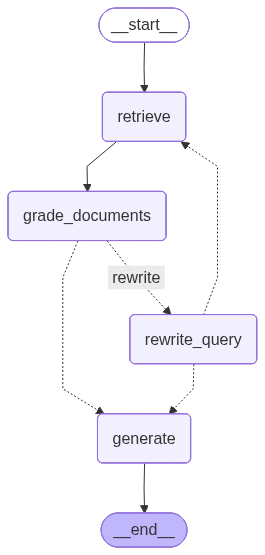

In [69]:

# Show the agent
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))
